In [15]:
import numpy as np

N = 6
R = 4

# Adjacency tensor
A = np.zeros((N, N, R), dtype=int)

# ------------------
# Relation 0
# ------------------
A[0,1,0] = A[1,0,0] = 1
A[1,2,0] = A[2,1,0] = 1

# ------------------
# Relation 1
# ------------------
A[2,3,1] = A[3,2,1] = 1
A[3,4,1] = A[4,3,1] = 1

# ------------------
# Relation 2
# ------------------
A[0,5,2] = A[5,0,2] = 1
A[1,5,2] = A[5,1,2] = 1

# ------------------
# Relation 3
# ------------------
A[2,4,3] = A[4,2,3] = 1
A[0,3,3] = A[3,0,3] = 1

D = np.zeros_like(A)

for r in range(R):
    deg = A[:, :, r].sum(axis=1)
    D[:, :, r] = np.diag(deg)

print("Adjacency shape:", A.shape)
print("Degree shape:", D.shape)

Adjacency shape: (6, 6, 4)
Degree shape: (6, 6, 4)


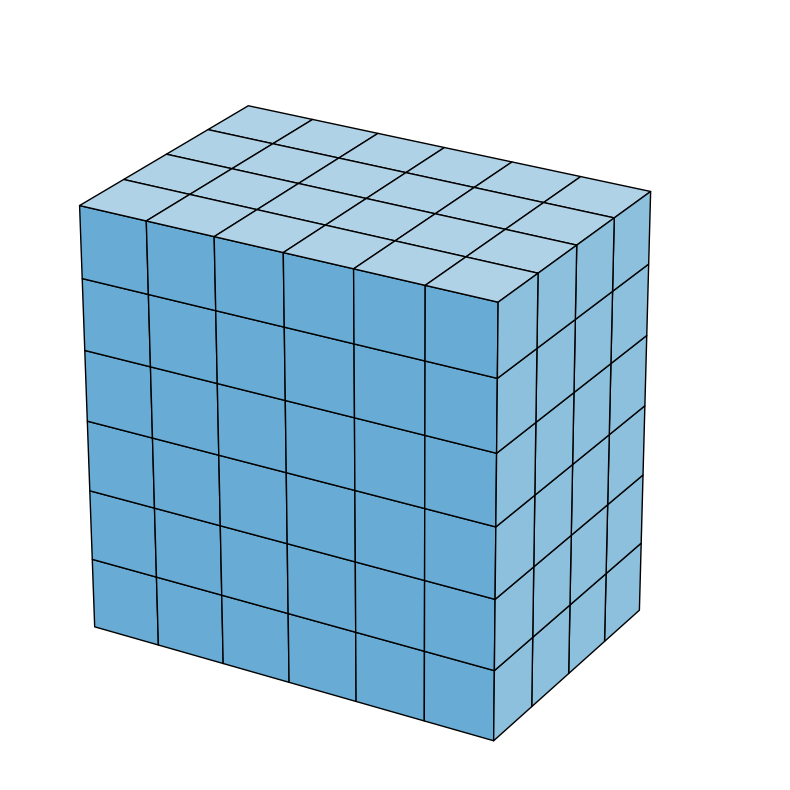

In [16]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib import cm

# ==========================================
# Parameters
# ==========================================
N = 6                   # grid size
cmap = cm.Blues
# np.random.seed(42)

# Values for coloring
front_vals = np.random.choice([1], (N, N)) #np.random.rand(N, N)
top_vals   = np.random.choice([1], (N, N)) #np.random.rand(N, N)
side_vals  = np.random.choice([1], (N, N)) #np.random.rand(N, N)

# front_vals = A[:, :, 0].T
# top_vals   = A[0, :, :].T
# side_vals  = A[:, 0, :]

# for i in range(6):
#     for j in range(6):
#         if i != j:
#             front_vals[i, j] = 0
#             # top_vals[i, j] = 0
#             # side_vals[i, j] = 0
# ==========================================
# Figure
# ==========================================
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# ==========================================
# Front face (y=0)
# ==========================================
for i in range(N):
    for j in range(N):
        verts = [[
            (j, 0, i),
            (j+1, 0, i),
            (j+1, 0, i+1),
            (j, 0, i+1)
        ]]

        color = cmap(0.01 + 0.5*front_vals[i, j])

        poly = Poly3DCollection(
            verts,
            facecolors=color,
            edgecolors='black',
            linewidths=1.0
        )
        ax.add_collection3d(poly)

# ==========================================
# Top face (z=N)
# ==========================================
for i in range(N-2):
    for j in range(N):
        verts = [[
            (j, i, N),
            (j+1, i, N),
            (j+1, i+1, N),
            (j, i+1, N)
        ]]

        color = cmap(0.02 + 0.3*top_vals[i, j])

        poly = Poly3DCollection(
            verts,
            facecolors=color,
            edgecolors='black',
            linewidths=1.0
        )
        ax.add_collection3d(poly)

# ==========================================
# Right face (x=N)
# ==========================================
for i in range(N):
    for j in range(N-2):
        verts = [[
            (N, j, i),
            (N, j+1, i),
            (N, j+1, i+1),
            (N, j, i+1)
        ]]

        color = cmap(0.02 + 0.4*side_vals[i, j])

        poly = Poly3DCollection(
            verts,
            facecolors=color,
            edgecolors='black',
            linewidths=1.0
        )
        ax.add_collection3d(poly)

# ==========================================
# Formatting
# ==========================================
ax.set_xlim(0, N)
ax.set_ylim(0, N)
ax.set_zlim(0, N)

ax.set_box_aspect([1,1,1])

# View similar to the generated image
ax.view_init(elev=25, azim=-60)

# Remove axes
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_axis_off()

fig.patch.set_facecolor('none')
ax.set_facecolor('none')

plt.tight_layout()
plt.show()

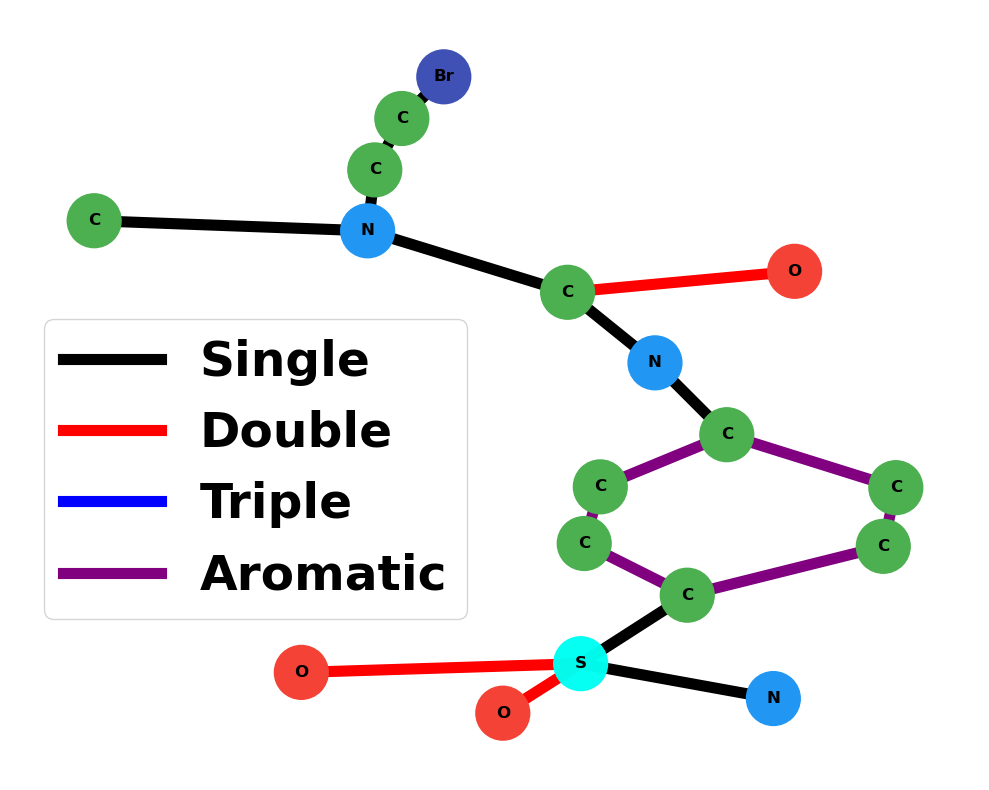

In [18]:
from rdkit import Chem
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Aspirin SMILES
smiles = "BrCCN(C)C(=O)Nc1ccc(S(=O)(=O)N)cc1"

# Create molecule
mol = Chem.MolFromSmiles(smiles)

# Create graph
G = nx.Graph()

# ---------------------------
# Atom colors
# ---------------------------
atom_colors_map = {
    'C': '#4CAF50',   # green
    'O': '#F44336',   # red
    'N': '#2196F3',   # blue
    'S': "#00FFF2F9",   # orange
    'P': '#9C27B0',   # purple
    'F': '#00BCD4',   # cyan
    'Cl': '#795548',  # brown
    'Br': '#3F51B5',  # indigo
    'I': '#607D8B'    # blue-grey
}

# ---------------------------
# Bond colors
# ---------------------------
bond_colors_map = {
    Chem.rdchem.BondType.SINGLE: 'black',
    Chem.rdchem.BondType.DOUBLE: 'red',
    Chem.rdchem.BondType.TRIPLE: 'blue',
    Chem.rdchem.BondType.AROMATIC: 'purple'
}

# Add atoms
for atom in mol.GetAtoms():
    idx = atom.GetIdx()
    symbol = atom.GetSymbol()
    G.add_node(idx, label=symbol, color=atom_colors_map.get(symbol, 'gray'))

# Add bonds
for bond in mol.GetBonds():
    i = bond.GetBeginAtomIdx()
    j = bond.GetEndAtomIdx()
    G.add_edge(i, j, color=bond_colors_map.get(bond.GetBondType(), 'gray'))

# Layout
pos = nx.spring_layout(G, seed=42)

# Node colors
node_colors = [G.nodes[n]['color'] for n in G.nodes()]

# Edge colors
edge_colors = [G.edges[e]['color'] for e in G.edges()]

# Labels
labels = {n: G.nodes[n]['label'] for n in G.nodes()}

# Draw

## For non-transparent background
# plt.figure(figsize=(8, 6))

## For transparent background
fig = plt.figure(figsize=(10, 8), facecolor='none')
ax = plt.gca()
ax.set_facecolor('none')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=8)
nx.draw_networkx_labels(G, pos, labels, font_size=12, font_weight='bold')

bond_legend = [
    Line2D([0], [0], color='black', lw=8, label='Single'),
    Line2D([0], [0], color='red', lw=8, label='Double'),
    Line2D([0], [0], color='blue', lw=8, label='Triple'),
    Line2D([0], [0], color='purple', lw=8, label='Aromatic'),
]

# atom_legend = [
#     Line2D([0], [0], marker='o', color='w',
#            markerfacecolor=v, markersize=10, label=k)
#     for k, v in atom_colors.items()
# ]

leg1 = plt.legend(
    handles=bond_legend,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.63),
    prop={
        'size': 35,
        'weight': 'bold'
    }
)

# plt.title("Aspirin Molecular Graph")
plt.axis("off")
plt.tight_layout()
plt.show()

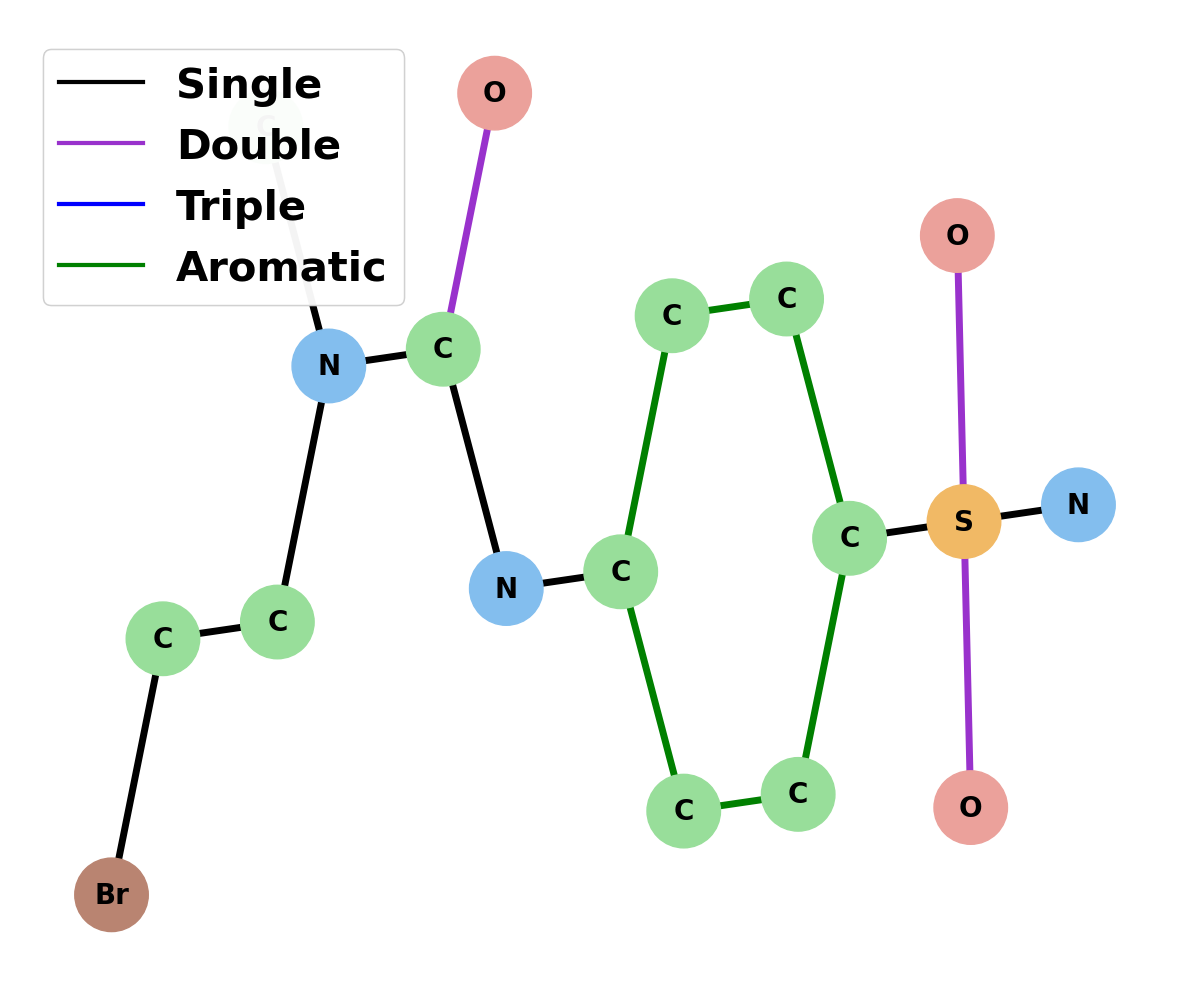

In [4]:
from rdkit import Chem
from rdkit.Chem import AllChem
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

smiles = 'BrCCN(C)C(=O)Nc1ccc(S(=O)(=O)N)cc1' #"ClC1=CC(=CC=C1C#N)S(=O)(=O)NCC=CBr"
mol = Chem.MolFromSmiles(smiles)

# Generate 2D coordinates
AllChem.Compute2DCoords(mol)

G = nx.Graph()

atom_colors = {
    'C': "#98DE9A",   # green
    'N': "#83BEEE",   # blue
    'O': "#EBA19B",   # red
    'S': "#F1B965",   # orange
    'Cl': "#DC90E9",  # purple
    'Br': "#B98471",  # brown
}


bond_colors = {
    Chem.rdchem.BondType.SINGLE: 'black',
    Chem.rdchem.BondType.DOUBLE: 'darkorchid',
    Chem.rdchem.BondType.TRIPLE: 'blue',
    Chem.rdchem.BondType.AROMATIC: 'green'
}

# Add atoms
for atom in mol.GetAtoms():
    G.add_node(
        atom.GetIdx(),
        label=atom.GetSymbol(),
        color=atom_colors.get(atom.GetSymbol(), "gray")
    )

# Add bonds
for bond in mol.GetBonds():
    G.add_edge(
        bond.GetBeginAtomIdx(),
        bond.GetEndAtomIdx(),
        color=bond_colors.get(bond.GetBondType(), "gray")
    )

# Use RDKit coordinates
conf = mol.GetConformer()
pos = {
    atom.GetIdx(): (
        conf.GetAtomPosition(atom.GetIdx()).x,
        conf.GetAtomPosition(atom.GetIdx()).y
    )
    for atom in mol.GetAtoms()
}

# pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 10))

nx.draw_networkx_edges(
    G, pos,
    edge_color=[G[u][v]['color'] for u, v in G.edges()],
    width=5
)

nx.draw_networkx_nodes(
    G, pos,
    node_color=[G.nodes[n]['color'] for n in G.nodes()],
    node_size=2800
)

nx.draw_networkx_labels(
    G, pos,
    labels=nx.get_node_attributes(G, 'label'),
    font_size=20,
    font_weight='bold'
)

# -------------------
# Legends
# -------------------

bond_legend = [
    Line2D([0], [0], color='black', lw=3, label='Single'),
    Line2D([0], [0], color='darkorchid', lw=3, label='Double'),
    Line2D([0], [0], color='blue', lw=3, label='Triple'),
    Line2D([0], [0], color='green', lw=3, label='Aromatic'),
]

# atom_legend = [
#     Line2D([0], [0], marker='o', color='w',
#            markerfacecolor=v, markersize=10, label=k)
#     for k, v in atom_colors.items()
# ]

leg1 = plt.legend(
    handles=bond_legend,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    prop={
        'size': 30,
        'weight': 'bold'
    }
)

plt.gca().add_artist(leg1)

# plt.legend(
#     handles=atom_legend,
#     title="Atom Types",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 0.55)
# )

plt.axis("off")
plt.tight_layout()
plt.show()

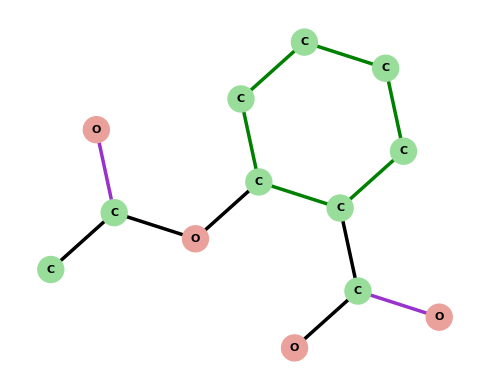

In [5]:
from rdkit import Chem
from rdkit.Chem import AllChem
import networkx as nx
import matplotlib.pyplot as plt

smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"  # Aspirin
mol = Chem.MolFromSmiles(smiles)

# Generate 2D coordinates
AllChem.Compute2DCoords(mol)

G = nx.Graph()

atom_colors = {
    'C': "#98DE9A",   # green
    'N': "#83BEEE",   # blue
    'O': "#EBA19B",   # red
    'S': "#F1B965",   # orange
    'Cl': "#DC90E9",  # purple
    'Br': "#B98471",  # brown
}

bond_colors = {
    Chem.rdchem.BondType.SINGLE: 'black',
    Chem.rdchem.BondType.DOUBLE: 'darkorchid',
    Chem.rdchem.BondType.TRIPLE: 'blue',
    Chem.rdchem.BondType.AROMATIC: 'green'
}

# Add atoms
for atom in mol.GetAtoms():
    G.add_node(
        atom.GetIdx(),
        label=atom.GetSymbol(),
        color=atom_colors.get(atom.GetSymbol(), "gray")
    )

# Add bonds
for bond in mol.GetBonds():
    G.add_edge(
        bond.GetBeginAtomIdx(),
        bond.GetEndAtomIdx(),
        color=bond_colors.get(bond.GetBondType(), "gray")
    )

# Use RDKit coordinates
conf = mol.GetConformer()
pos = {
    atom.GetIdx(): (
        conf.GetAtomPosition(atom.GetIdx()).x,
        conf.GetAtomPosition(atom.GetIdx()).y
    )
    for atom in mol.GetAtoms()
}

plt.figure(figsize=(5, 4))

nx.draw_networkx_edges(
    G, pos,
    edge_color=[G[u][v]['color'] for u, v in G.edges()],
    width=2.5
)

nx.draw_networkx_nodes(
    G, pos,
    node_color=[G.nodes[n]['color'] for n in G.nodes()],
    node_size=350
)

nx.draw_networkx_labels(
    G, pos,
    labels=nx.get_node_attributes(G, 'label'),
    font_size=8,
    font_weight='bold'
)

plt.axis("off")
plt.tight_layout()
plt.show()

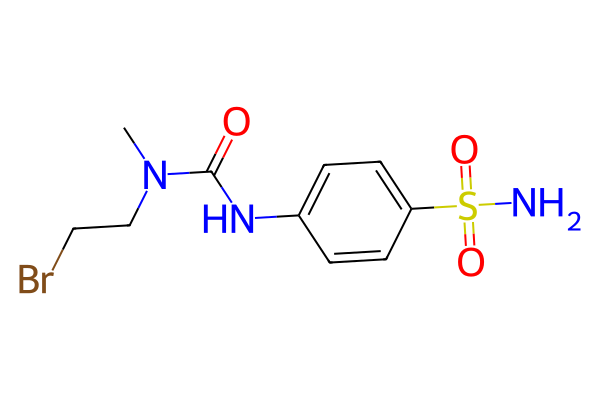

In [10]:
from data_utils_smiles import plot_molecule

plot_molecule('BrCCN(C)C(=O)Nc1ccc(S(=O)(=O)N)cc1', transparent_background=True)

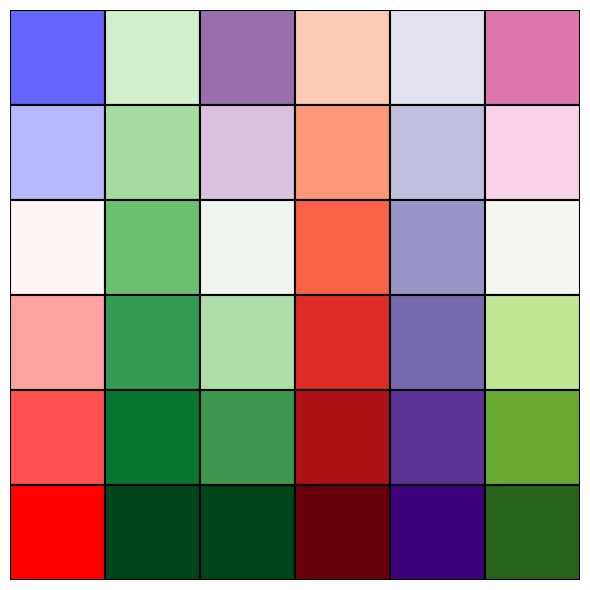

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import cm

# Grid size
n = 6

# Different colormap for each column
cmaps = [
    cm.bwr,
    cm.Greens,
    cm.PRGn,
    cm.Reds,
    cm.Purples,
    cm.PiYG
]

# Example values (rows increase from top to bottom)
values = np.linspace(0.2, 1.0, n)

fig, ax = plt.subplots(figsize=(6, 6))

for row in range(n):
    for col in range(n):

        # Value determines shade within the column's colormap
        color = cmaps[col](values[row])

        rect = Rectangle(
            (col, n-1-row),      # (x, y)
            1,                   # width
            1,                   # height
            facecolor=color,
            edgecolor='black',
            linewidth=1.5
        )

        ax.add_patch(rect)

# Formatting
ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.set_aspect('equal')

# Remove ticks and tick labels
ax.set_xticks([])
ax.set_yticks([])

# Remove the axis frame
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()